In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 8/12 #NOTE: changed!
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# Source parameters
#NOTE: this is the midSNR injection.  
# snr 30 1 yr plunging case (should peak abt snr 25 for 8mth)
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 7.7 #NOTE
e0 = 0.4
xI0 = 1.0
dist =  6 #NOTE: 
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                         
                 

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True, 
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.5, 6.3]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.5, 6.3]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=0.6666666666666666yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/stage1/int_s12_snr30'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.651305  ,  0.648015  ,  0.833405  ,  0.234015  ,  0.496335  ],
        [ 0.64974762,  0.63500014,  0.82274006,  0.23168725,  0.50492926],
        [ 0.65249266,  0.63308769,  0.82603348,  0.24105692,  0.4962674 ],
        ...,
        [ 1.5054957 ,  0.20790726,  0.40986246,  0.02075758,  0.93770477],
        [ 0.64596006, -0.45136744,  0.408676  ,  0.61240597,  0.36522601],
        [ 0.86819522, -0.07512357,  0.76010269,  0.11666496,  0.30872617]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([16.22744739, 15.03470557, 14.54532096, ...,        -inf,
               -inf,        -inf])]

In [7]:
sampler.now_covariances

[array([[ 0.04147409,  0.03472272, -0.01733769, -0.04059817,  0.00292473],
        [ 0.03472272,  0.18460412, -0.00473998,  0.00557801,  0.004751  ],
        [-0.01733769, -0.00473998,  0.1891968 , -0.03521546, -0.00517243],
        [-0.04059817,  0.00557801, -0.03521546,  0.21138746,  0.01854485],
        [ 0.00292473,  0.004751  , -0.00517243,  0.01854485,  0.17609459]])]

In [8]:
np.argmax(logden_list)

3

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.02383241, 1.12592747, 0.87314815, 7.68257927, 0.34387809]])

In [10]:
log_density(maxld_pt1)

array([16.43698314])

In [11]:
log_density([param_true])

array([25.03443669])

In [12]:
param_ranges = [(5.5,6.3),
                (0.8,1.3),
                (0.3,0.99),
                (7.0,10.0),
                (0.2,0.5),
                ]
param_ranges

[(5.5, 6.3), (0.8, 1.3), (0.3, 0.99), (7.0, 10.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 7.7, 0.4]

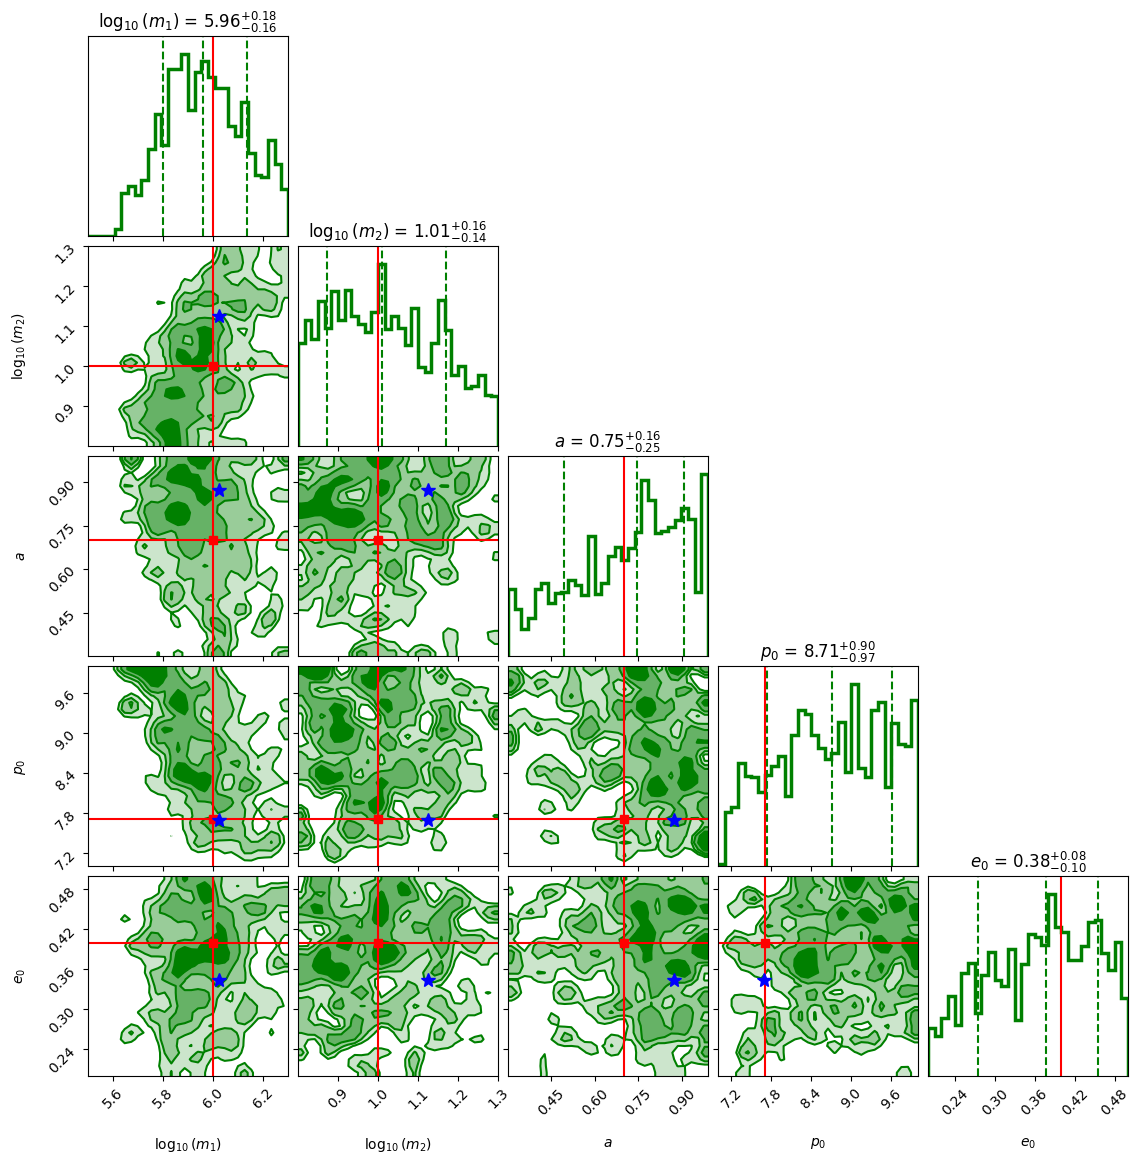

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[       -inf,        -inf,        -inf, ..., 15.88391058,
        16.22744739, 16.43698314]])

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([   3,    0,   61,   72,  906,   10,  305, 1255, 2179,  847])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[6.02383241, 1.12592747, 0.87314815, 7.68257927, 0.34387809],
       [6.021044  , 1.1240075 , 0.87504945, 7.702045  , 0.3489005 ],
       [6.0204916 , 1.12700863, 0.8673299 , 7.71053967, 0.35064197],
       [6.03357159, 1.13544445, 0.8847469 , 7.59574158, 0.33964418],
       [5.90911706, 0.96716234, 0.86942729, 7.52065914, 0.38025692],
       [6.02134448, 1.12669831, 0.87349114, 7.70559943, 0.3473564 ],
       [6.03323577, 1.12864581, 0.8866519 , 7.58105109, 0.33424449],
       [5.78846771, 0.92240516, 0.77295387, 8.41992208, 0.38643525],
       [5.74243272, 0.82835991, 0.79937779, 9.65662678, 0.41664754],
       [5.90467956, 1.11255435, 0.93972933, 8.45246503, 0.33294528]])

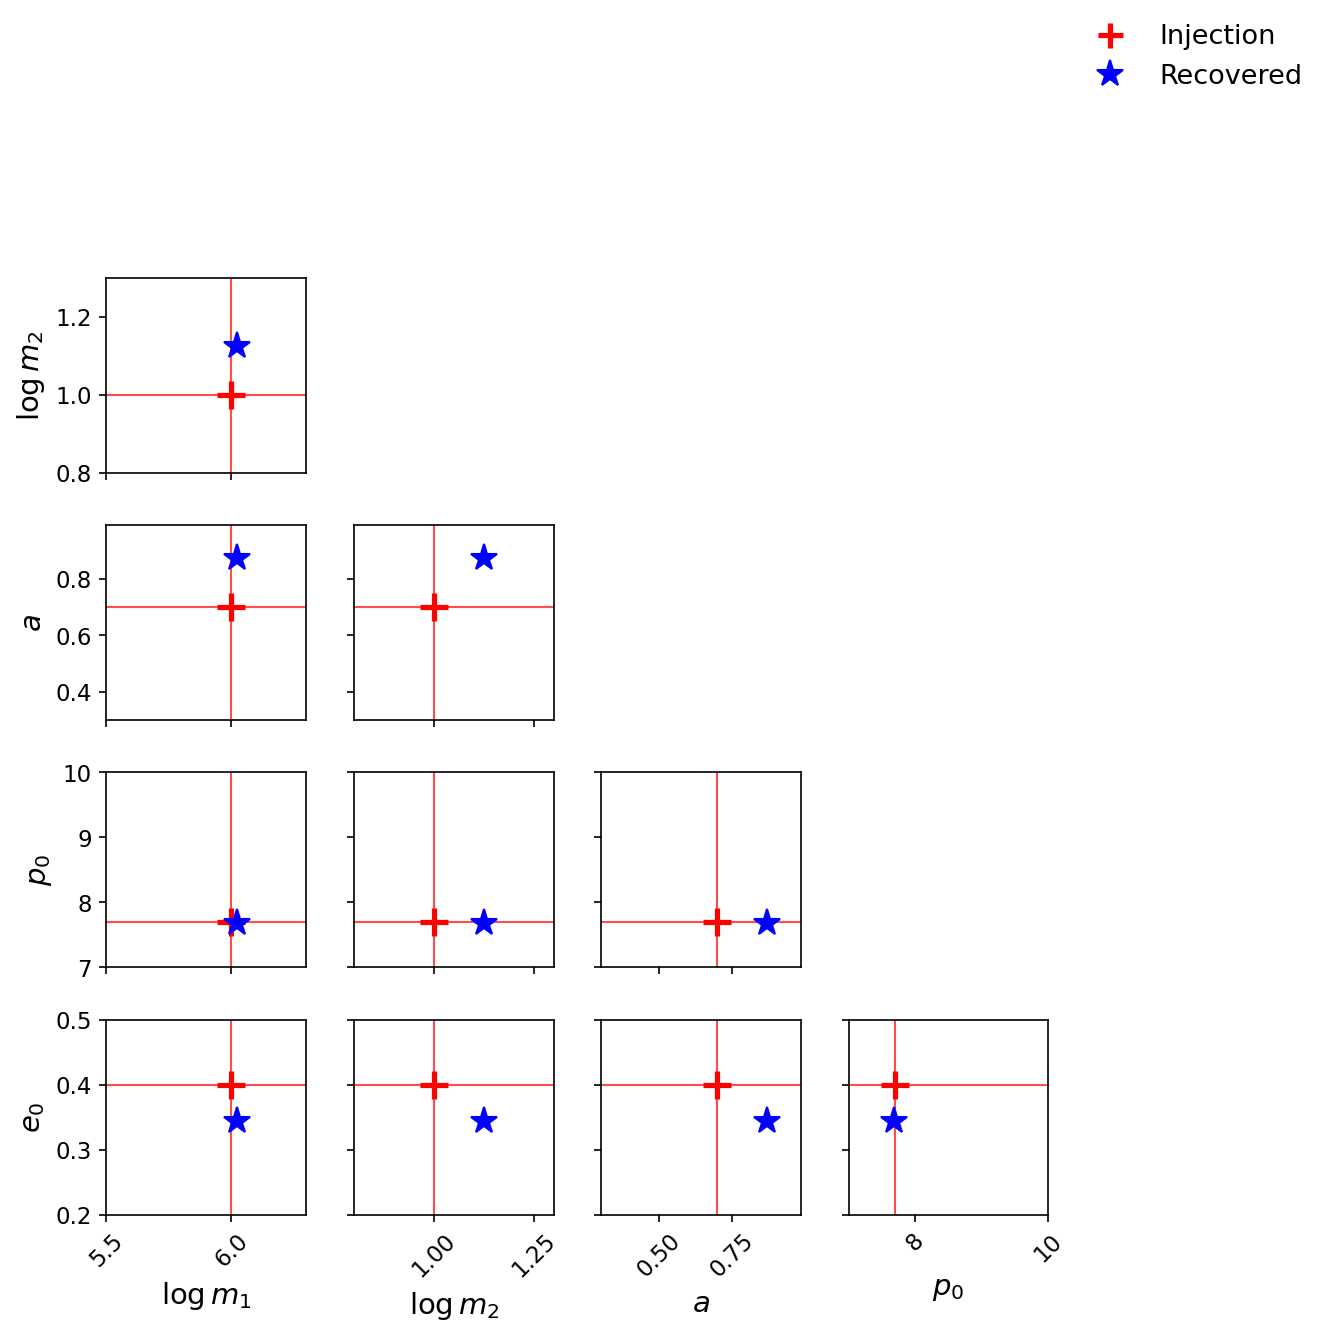

In [18]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

In [19]:
np.average(top10_pts.T[0])

5.949821690253158

In [20]:
np.average(top10_pts.T[1])

1.0598213931206613

In [21]:
np.average(top10_pts.T[2])

0.8641905729738604

In [22]:
np.average(top10_pts.T[3])

8.002722905495249

In [23]:
np.average(top10_pts.T[4])

0.35809506111895384

In [24]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [25]:
import matplotlib.pyplot as plt

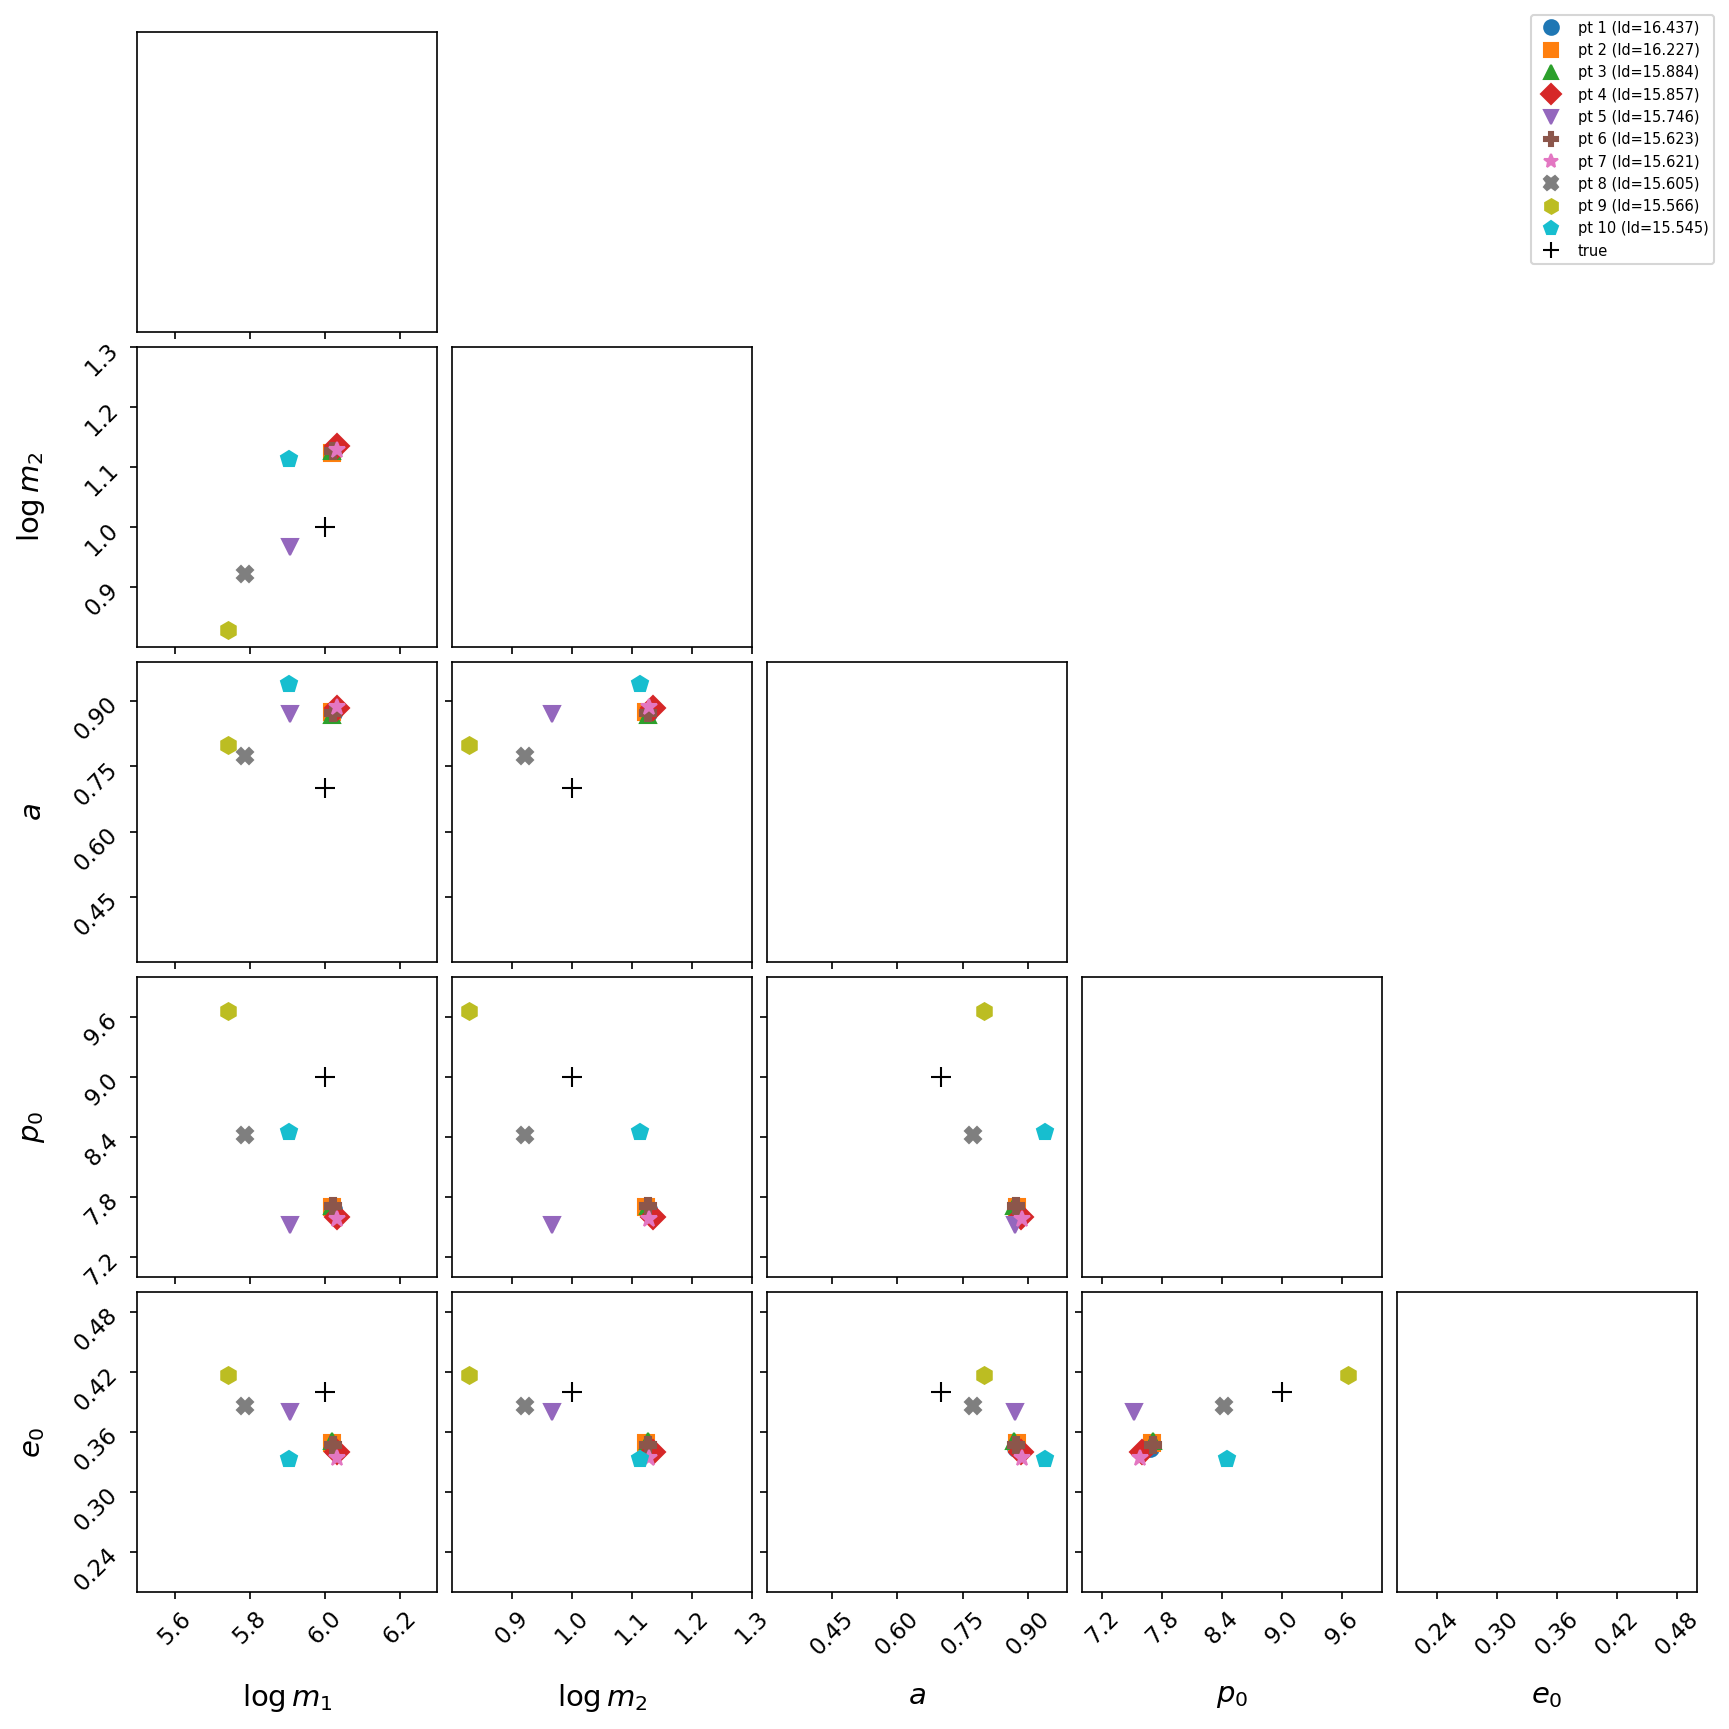

In [26]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=param_ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(param_ranges[col])
        if col < row:
            axes[row, col].set_ylim(param_ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

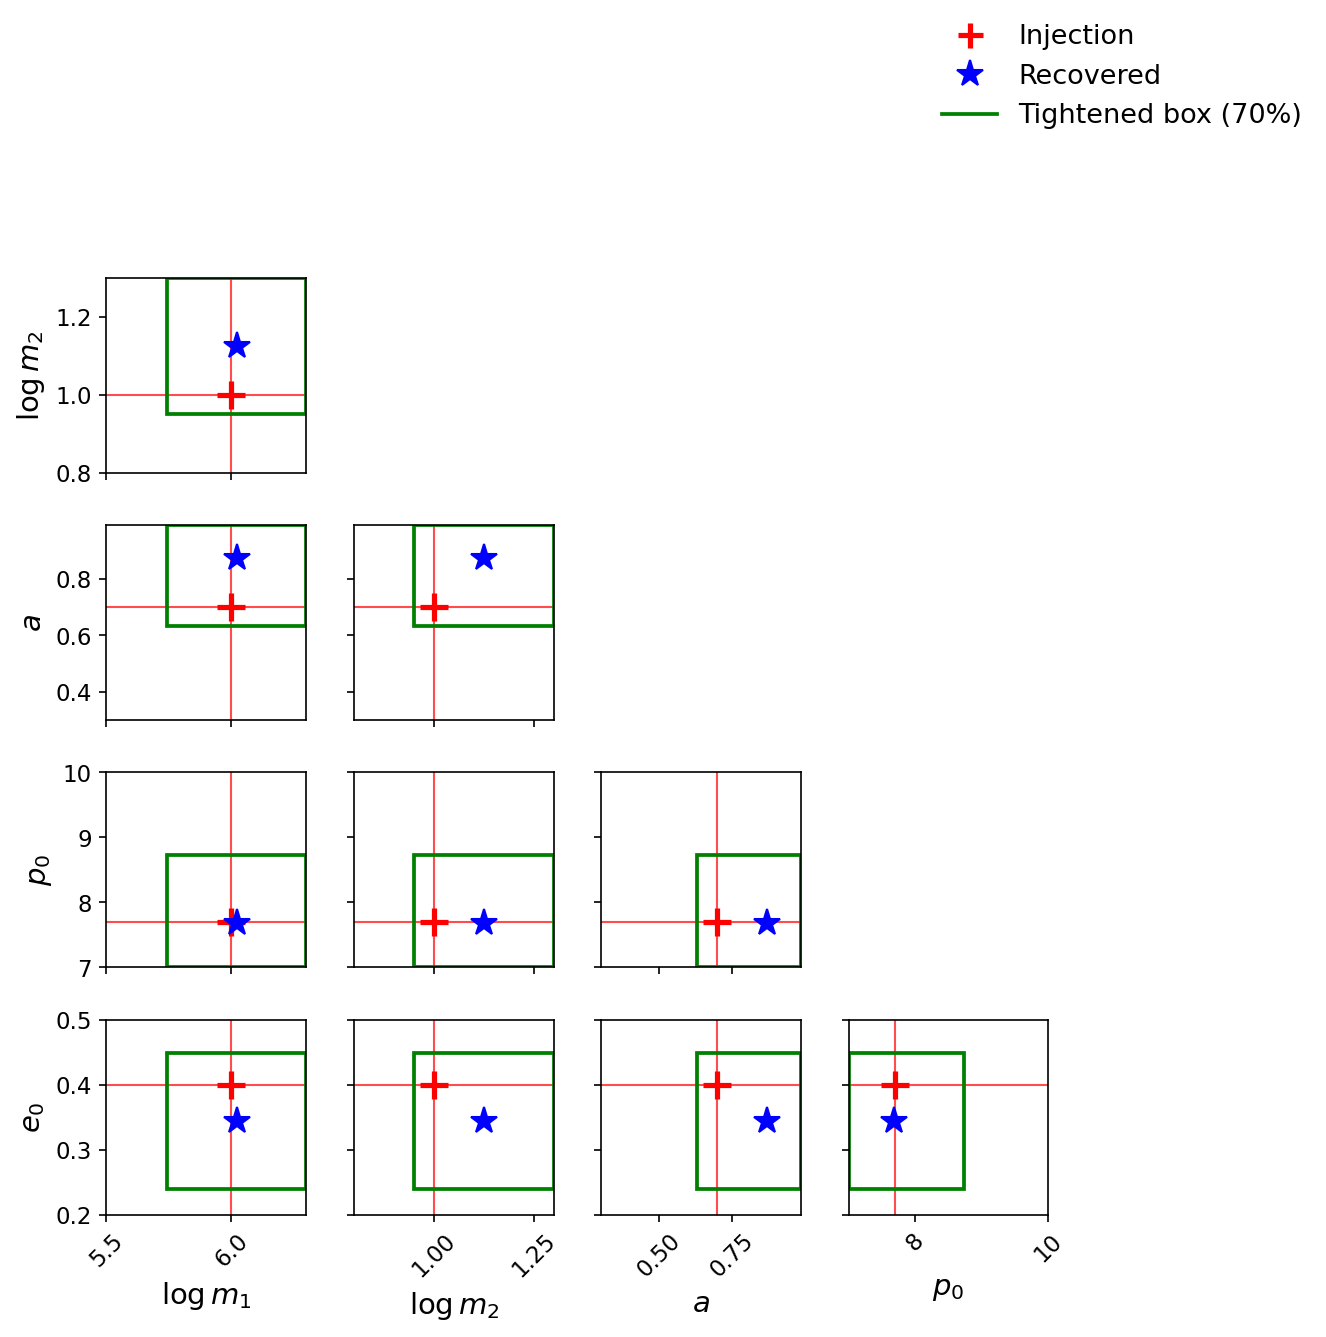

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

# tightened box: frac of the original width, centered on the MAP point,
# clipped back to the original box
frac = 0.7
old_lo = np.array([r[0] for r in param_ranges])
old_hi = np.array([r[1] for r in param_ranges])
old_width = old_hi - old_lo
box_lo = np.maximum(maxld_pt1 - frac / 2 * old_width, old_lo)
box_hi = np.minimum(maxld_pt1 + frac / 2 * old_width, old_hi)

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # tightened (70%) box overlay
        ax.add_patch(Rectangle(
            (box_lo[j], box_lo[i]),
            box_hi[j] - box_lo[j],
            box_hi[i] - box_lo[i],
            facecolor='none', edgecolor='green', lw=1.8, zorder=2,
        ))

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
    Line2D([0], [0], color='green', lw=1.8,                            label='Tightened box (70%)'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

In [28]:
old_lo = np.array([r[0] for r in param_ranges])
old_hi = np.array([r[1] for r in param_ranges])
old_width = old_hi - old_lo

center = maxld_pt1.reshape(-1)          # MAP point
true_pt = np.asarray(param_true).ravel()

frac = 0.7   # e.g. keep 70% of the original box width, centered on MAP

new_lo = center - frac/2 * old_width
new_hi = center + frac/2 * old_width

# clip back to the original (physical) box so you never expand beyond it
new_lo = np.maximum(new_lo, old_lo)
new_hi = np.minimum(new_hi, old_hi)

new_param_ranges = list(zip(new_lo, new_hi))

contains_truth = np.all(new_lo <= true_pt) & np.all(true_pt <= new_hi)
print("contains truth:", contains_truth)
for lbl, lo, hi, t in zip(labels, new_lo, new_hi, true_pt):
    print(f"{lbl}: [{lo:.4f}, {hi:.4f}]  truth={t:.4f}  {'OK' if lo<=t<=hi else 'CUT'}")


contains truth: True
$\log m_1$: [5.7438, 6.3000]  truth=6.0000  OK
$\log m_2$: [0.9509, 1.3000]  truth=1.0000  OK
$a$: [0.6316, 0.9900]  truth=0.7000  OK
$p_0$: [7.0000, 8.7326]  truth=7.7000  OK
$e_0$: [0.2389, 0.4489]  truth=0.4000  OK


# connection plot

In [27]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.02383241, 1.12592747, 0.87314815, 7.68257927, 0.34387809]])

In [28]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [29]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [30]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [31]:
logden_theory_proc1

array([16.43698314, 15.63733146, 15.34666813, 15.99644267, 15.67154814,
       15.54283214, 14.87702308, 15.03741417, 15.31875126, 15.20772605,
       15.53294091, 15.06900915, 14.52086819, 15.02053209, 14.81517627,
       15.06479817, 15.31165055, 15.01127799, 14.65668101, 14.88005239,
       14.93377701, 15.04358568, 14.55045037, 15.5435083 , 14.62588005,
       14.89966943, 15.51972824, 15.13493962, 15.37261238, 15.24496018,
       15.17735135, 15.2482007 , 15.90888331, 15.21604085, 15.30841405,
       15.33001149, 16.03203154, 16.02575277, 15.56768606, 15.56520544,
       16.20399253, 14.98256854, 15.3807675 , 15.81452987, 15.8510837 ,
       16.04602228, 15.70280709, 15.56551826, 16.15843324, 25.03443669])

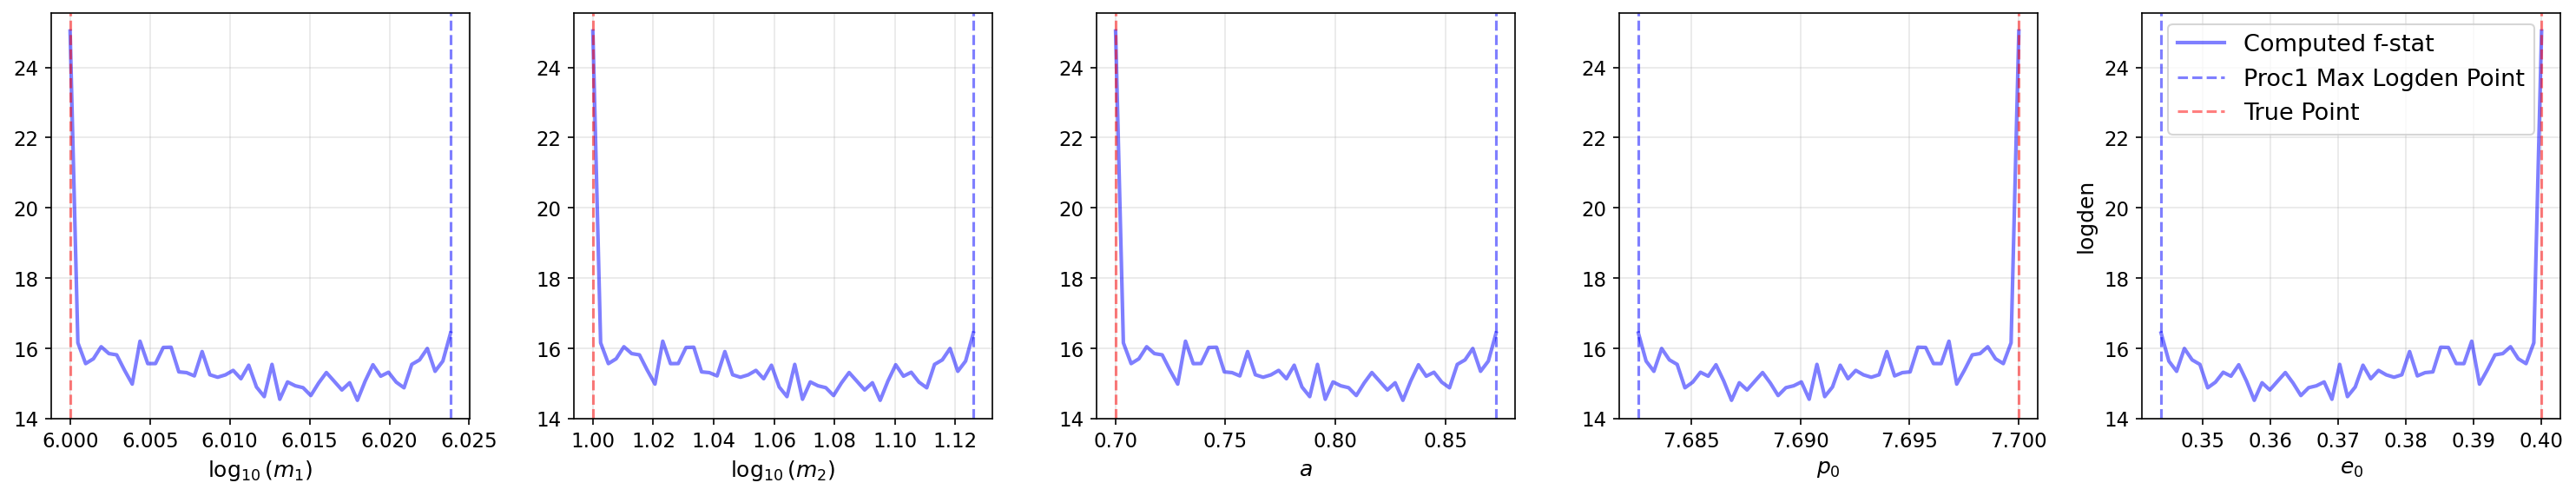

In [32]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [33]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [34]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [35]:
logden_tm = log_density(line_points_logm1.T)


In [36]:
logden_tm

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
       14.61509491, 16.24014344, 15.65923162, 15.38056485, 16.43

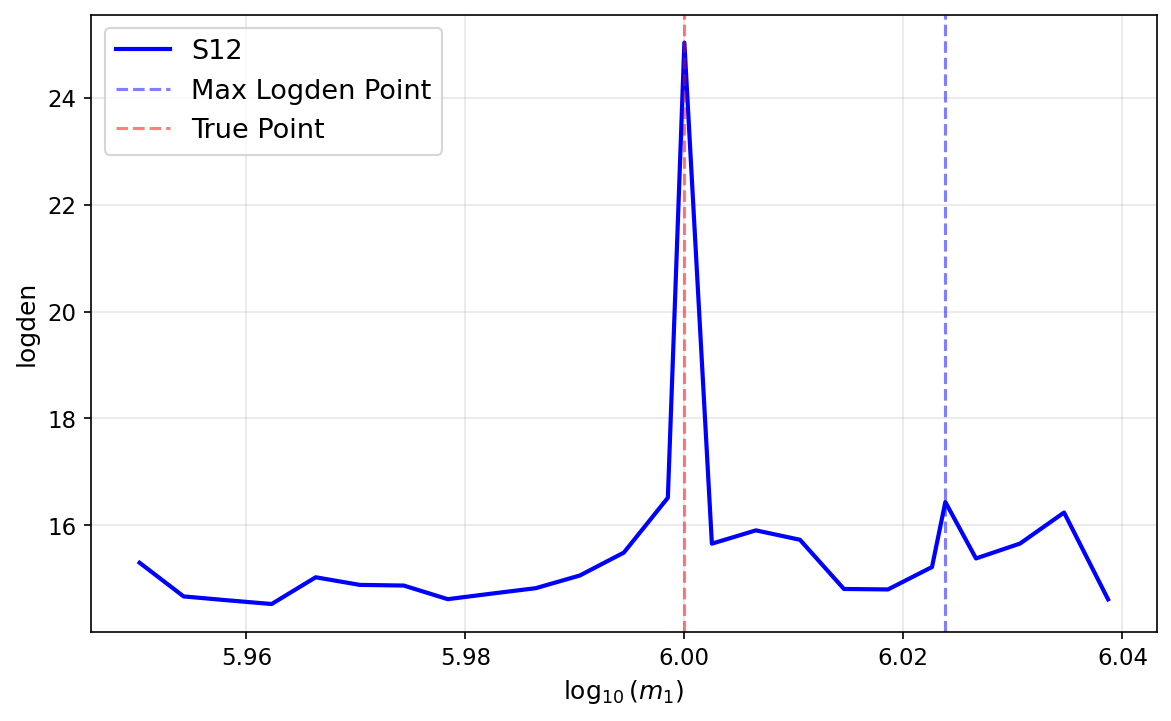

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S12')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()